# Drone Delivery Optimization

## 1. Business Understanding

The company wants to improve delivery efficiency by determining optimal depot locations and increase revenue through product recommendations based on purchase behavior.

## 2. Data Understanding

Datasets:

- drone_cust_locations.csv
- drone_prod_groups.csv

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

cust_df = pd.read_csv('C:/Data/drone_cust_locations.csv', sep=';')
prod_df = pd.read_csv('C:/Data/drone_prod_groups.csv', sep=';')

cust_df.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


### Explore Customer Locations

The following analysis visualizes customers and identifies natural geographic groupings.

In [11]:
cust_df.info()
cust_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  5956 non-null   int64  
 1   x         5956 non-null   float64
 2   y         5956 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 139.7 KB


,clientid,x,y
count,5956.000000,5956.000000,5956.000000
mean,2978.500000,508.823177,427.554772
std,1719.493433,271.061462,289.044640
min,1.000000,0.017692,0.043285
25%,1489.750000,282.582920,170.079921
50%,2978.500000,518.100892,397.786441
75%,4467.250000,727.156497,669.982518
max,5956.000000,999.533215,999.731720


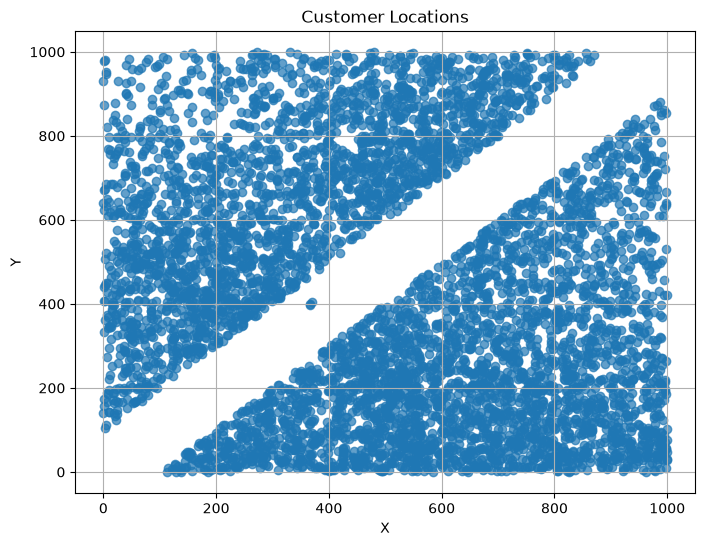

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(cust_df["x"], cust_df["y"], alpha=0.7)
plt.title("Customer Locations")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

## 3. Data Preparation

In [13]:
X = cust_df[["x","y"]]

## 4. Modeling: Depot Optimization

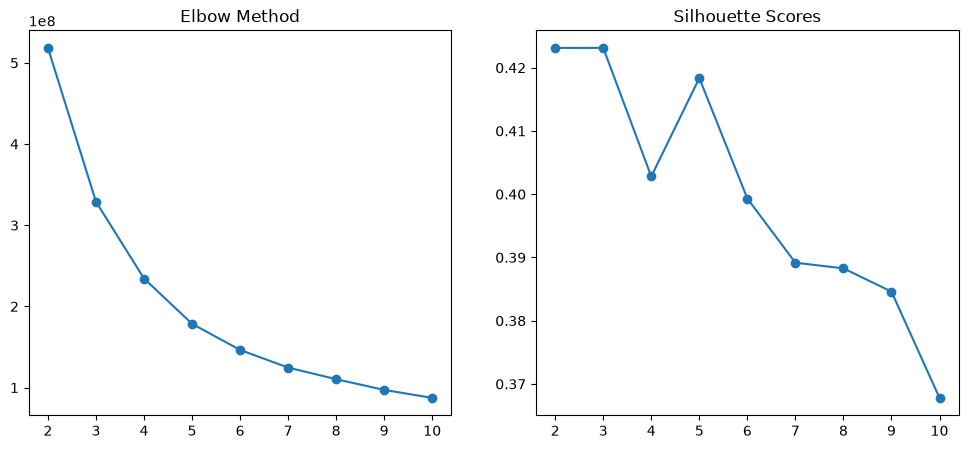

In [14]:
inertia=[]
sil=[]
for k in range(2,11):
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].plot(range(2,11), inertia, marker="o")
ax[0].set_title("Elbow Method")
ax[1].plot(range(2,11), sil, marker="o")
ax[1].set_title("Silhouette Scores")
plt.show()

            x           y
0  194.409092  393.312949
1  697.395271  210.101185
2  554.215782  787.789998


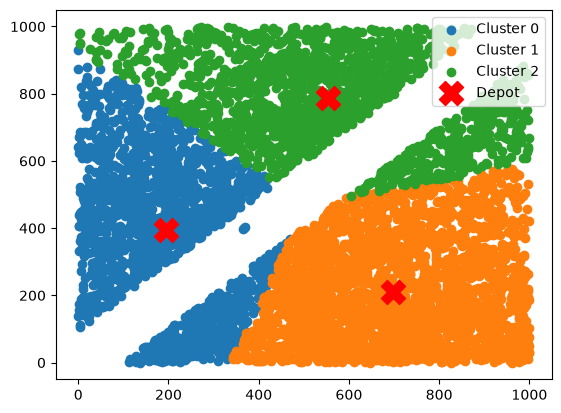

In [15]:
kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
cust_df["Cluster"]=kmeans.fit_predict(X)
centroids=kmeans.cluster_centers_

print(pd.DataFrame(centroids, columns=["x","y"]))

for c in sorted(cust_df.Cluster.unique()):
    d=cust_df[cust_df.Cluster==c]
    plt.scatter(d.x,d.y,label=f"Cluster {c}")

plt.scatter(centroids[:,0],centroids[:,1],c="red",marker="X",s=300,label="Depot")
plt.legend()
plt.show()

### Hierarchical Clustering Comparison

K-Means is generally preferable for depot placement because cluster centroids directly provide recommended hub coordinates.

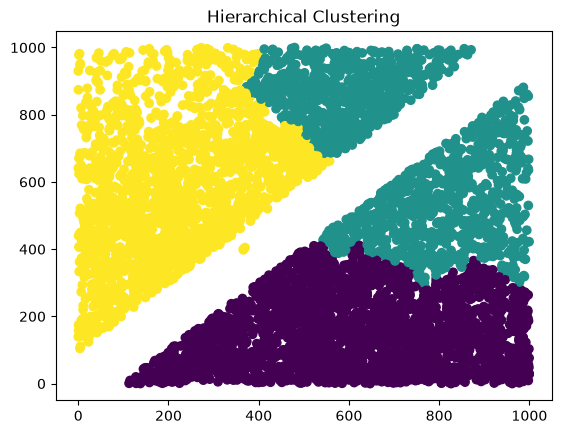

In [16]:
hc=AgglomerativeClustering(n_clusters=3)
labels=hc.fit_predict(X)
plt.scatter(cust_df.x,cust_df.y,c=labels,cmap="viridis")
plt.title("Hierarchical Clustering")
plt.show()

## 5. Association Rule Mining

In [17]:
prod_df = pd.read_csv('C:/Data/drone_prod_groups.csv', sep=',')
transactions = prod_df.drop(columns=["ID"]).astype(bool)
frequent_itemsets = apriori(transactions, min_support=0.05, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False).head()

,support,itemsets
14,0.20626,frozenset({ Prod19})
5,0.19853,frozenset({ Prod9})
4,0.16179,frozenset({ Prod8})
8,0.15971,frozenset({ Prod12})
15,0.14798,frozenset({ Prod20})


In [18]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules.sort_values(["lift","confidence"], ascending=False)
rules[["antecedents","consequents","support","confidence","lift"]].head(20)

,antecedents,consequents,support,confidence,lift
1,frozenset({ Prod15}),frozenset({ Prod9}),0.11145,0.938131,4.725388
2,frozenset({ Prod9}),frozenset({ Prod15}),0.11145,0.561376,4.725388
4,frozenset({ Prod20}),frozenset({ Prod19}),0.13476,0.910664,4.415125
3,frozenset({ Prod19}),frozenset({ Prod20}),0.13476,0.653350,4.415125
0,frozenset({ Prod5}),frozenset({ Prod12}),0.06683,0.638971,4.000822


## 6. Evaluation

Strong clustering results indicate geographically coherent service regions. Strong association rules indicate predictable purchasing behaviour suitable for recommendation systems and cross-selling campaigns.

## Deployment

## Depot Strategy
- Establish depots at the k-means centroids.
- Assign customers to the nearest depot.
- Recalculate clusters periodically.
- Consider additional hubs if future demand grows.

## Revenue Growth Strategy
- Recommend products based on high-lift rules.
- Create product bundles.
- Use targeted promotions.
- Increase average basket value through cross-selling.

## Conclusion

The analysis addresses both operational optimization and revenue growth. K-means clustering identifies efficient depot locations that reduce travel distance, while association rule mining identifies valuable product relationships that can be used in recommendation systems and marketing campaigns. Together these approaches support improved efficiency, customer service, and profitability.